# 데이터 및 패키지 불러오기

In [165]:
import pandas as pd #판다스 패키지 불러오기
import numpy as np

In [166]:
pd.set_option("display.max_columns", None) #모든 열을 보여줌

In [167]:
data_path='C:/Users/KGH/Desktop/data/프로젝트 빅콘테스트/2022빅콘테스트_데이터분석리그_데이터분석분야_퓨처스부문_데이터셋_220908'
user_df=pd.read_csv(data_path+'/user_spec.csv')
loan_df=pd.read_csv(data_path+'/loan_result.csv')
log_df=pd.read_csv(data_path+'/log_data.csv')

# 데이터 EDA

# 데이터 정보

In [168]:
user_df.head()

,application_id,user_id,birth_year,gender,insert_time,credit_score,yearly_income,income_type,company_enter_month,employment_type,houseown_type,desired_amount,purpose,personal_rehabilitation_yn,personal_rehabilitation_complete_yn,existing_loan_cnt,existing_loan_amt
0,1249046,118218,1985.0,1.0,2022-06-07 06:28:18,660.0,108000000.0,PRIVATEBUSINESS,20151101.0,기타,자가,1000000.0,기타,0.0,NaN,4.0,162000000.0
1,954900,553686,1968.0,1.0,2022-06-07 14:29:03,870.0,30000000.0,PRIVATEBUSINESS,20070201.0,정규직,기타가족소유,30000000.0,대환대출,0.0,NaN,1.0,27000000.0
2,137274,59516,1997.0,1.0,2022-06-07 21:40:22,710.0,30000000.0,FREELANCER,20210901.0,기타,기타가족소유,10000000.0,생활비,0.0,NaN,5.0,15000000.0
3,1570936,167320,1989.0,1.0,2022-06-07 09:40:27,820.0,62000000.0,EARNEDINCOME,20170101.0,정규직,자가,2000000.0,생활비,0.0,NaN,7.0,344000000.0
4,967833,33400,2000.0,1.0,2022-06-07 08:55:07,630.0,36000000.0,EARNEDINCOME,20210901.0,정규직,기타가족소유,5000000.0,생활비,0.0,0.0,1.0,16000000.0


In [169]:
loan_df.head()

,application_id,loanapply_insert_time,bank_id,product_id,loan_limit,loan_rate,is_applied
0,1748340,2022-06-07 13:05:41,7,191,42000000.0,13.6,NaN
1,1748340,2022-06-07 13:05:41,25,169,24000000.0,17.9,NaN
2,1748340,2022-06-07 13:05:41,2,7,24000000.0,18.5,NaN
3,1748340,2022-06-07 13:05:41,4,268,29000000.0,10.8,NaN
4,1748340,2022-06-07 13:05:41,11,118,5000000.0,16.4,NaN


In [170]:
log_df.head()

,user_id,event,timestamp,mp_os,mp_app_version,date_cd
0,576409,StartLoanApply,2022-03-25 11:12:09,Android,3.8.2,2022-03-25
1,576409,ViewLoanApplyIntro,2022-03-25 11:12:09,Android,3.8.2,2022-03-25
2,72878,EndLoanApply,2022-03-25 11:14:44,Android,3.8.4,2022-03-25
3,645317,OpenApp,2022-03-25 11:15:09,iOS,3.6.1,2022-03-25
4,645317,UseLoanManage,2022-03-25 11:15:11,iOS,3.6.1,2022-03-25


# 각 데이터 변수 명 바꿔주기

In [171]:
user_df.columns=['신청서_id','유저_id','생년월일','성별','생성일시','신용점수','연소득','근로형태'
                ,'입사연월','고용형태','주거소유형태','대출희망금액','대출목적','개인회생자여부'
                ,'개인회생자_납입완료여부','기대출수','기대출금액']
loan_df.columns=['신청서_id','한도조회일시','금융사_id','상품_id','승인한도','승인금리','신청여부']
log_df.columns=['유저_id','행동명','행동일시','OS','앱버전','날짜']

In [172]:
user_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1394216 entries, 0 to 1394215
Data columns (total 17 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   신청서_id        1394216 non-null  int64  
 1   유저_id         1394216 non-null  int64  
 2   생년월일          1381255 non-null  float64
 3   성별            1381255 non-null  float64
 4   생성일시          1394216 non-null  object 
 5   신용점수          1289101 non-null  float64
 6   연소득           1394126 non-null  float64
 7   근로형태          1394131 non-null  object 
 8   입사연월          1222456 non-null  float64
 9   고용형태          1394131 non-null  object 
 10  주거소유형태        1394131 non-null  object 
 11  대출희망금액        1394131 non-null  float64
 12  대출목적          1394131 non-null  object 
 13  개인회생자여부       806755 non-null   float64
 14  개인회생자_납입완료여부  190862 non-null   float64
 15  기대출수          1195660 non-null  float64
 16  기대출금액         1080442 non-null  float64
dtypes: float64(10), int64(2), o

In [173]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13527363 entries, 0 to 13527362
Data columns (total 7 columns):
 #   Column  Dtype  
---  ------  -----  
 0   신청서_id  int64  
 1   한도조회일시  object 
 2   금융사_id  int64  
 3   상품_id   int64  
 4   승인한도    float64
 5   승인금리    float64
 6   신청여부    float64
dtypes: float64(3), int64(3), object(1)
memory usage: 722.4+ MB


In [174]:
log_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17843993 entries, 0 to 17843992
Data columns (total 6 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   유저_id   int64 
 1   행동명     object
 2   행동일시    object
 3   OS      object
 4   앱버전     object
 5   날짜      object
dtypes: int64(1), object(5)
memory usage: 816.8+ MB


# 데이터 결측치

In [175]:
user_df.isnull().sum()

신청서_id                0
유저_id                 0
생년월일              12961
성별                12961
생성일시                  0
신용점수             105115
연소득                  90
근로형태                 85
입사연월             171760
고용형태                 85
주거소유형태               85
대출희망금액               85
대출목적                 85
개인회생자여부          587461
개인회생자_납입완료여부    1203354
기대출수             198556
기대출금액            313774
dtype: int64

In [176]:
loan_df.isnull().sum()

신청서_id          0
한도조회일시          0
금융사_id          0
상품_id           0
승인한도         7495
승인금리         7495
신청여부      3257239
dtype: int64

In [177]:
log_df.isnull().sum()

유저_id         0
행동명           0
행동일시          0
OS          980
앱버전      660597
날짜            0
dtype: int64

# user_df의 각 변수들 살펴보기

In [178]:
user_df["신청서_id"].value_counts()

6141       1
1665656    1
1688173    1
1694318    1
1649264    1
          ..
520788     1
522837     1
516694     1
518743     1
2097152    1
Name: 신청서_id, Length: 1394216, dtype: int64

In [179]:
user_df["유저_id"].value_counts()

377301    840
52440     501
162040    312
572113    220
509214    207
         ... 
197196      1
209482      1
219719      1
215621      1
2049        1
Name: 유저_id, Length: 405213, dtype: int64

In [180]:
user_df["생년월일"].value_counts()

1982.0    53165
1992.0    52441
1991.0    50495
1981.0    50409
1993.0    50118
          ...  
2008.0        7
1933.0        7
1930.0        2
1929.0        1
1927.0        1
Name: 생년월일, Length: 81, dtype: int64

In [181]:
user_df["성별"].value_counts()

1.0    934321
0.0    446934
Name: 성별, dtype: int64

In [182]:
user_df["생성일시"].value_counts()

2022-05-09 14:18:08    7
2022-04-25 09:17:06    6
2022-04-25 15:42:41    5
2022-04-25 10:51:47    5
2022-04-04 09:13:08    5
                      ..
2022-04-08 13:29:52    1
2022-06-16 15:47:05    1
2022-04-20 10:38:15    1
2022-03-31 12:14:46    1
2022-04-26 05:56:14    1
Name: 생성일시, Length: 1265510, dtype: int64

In [183]:
user_df["신용점수"].value_counts()

610.0    68436
590.0    67869
600.0    67519
580.0    64337
620.0    63305
         ...  
60.0         1
180.0        1
170.0        1
140.0        1
70.0         1
Name: 신용점수, Length: 91, dtype: int64

In [184]:
user_df["연소득"].value_counts()

3.000000e+07    135536
4.000000e+07     75535
5.000000e+07     70219
2.400000e+07     67082
2.500000e+07     55076
                 ...  
1.629000e+09         1
5.200000e+09         1
1.560000e+09         1
3.210000e+08         1
5.340000e+08         1
Name: 연소득, Length: 696, dtype: int64

In [185]:
user_df["근로형태"].value_counts()

EARNEDINCOME       892579
OTHERINCOME        172600
PRIVATEBUSINESS    126108
FREELANCER         103913
EARNEDINCOME2       78806
PRACTITIONER        20125
Name: 근로형태, dtype: int64

In [186]:
user_df["입사연월"].value_counts()

202201.0      46458
202203.0      32119
202112.0      32116
202202.0      32081
202111.0      31024
              ...  
20050303.0        1
20050311.0        1
20050724.0        1
20050810.0        1
20150612.0        1
Name: 입사연월, Length: 6719, dtype: int64

In [187]:
user_df["고용형태"].value_counts()

정규직    918032
기타     345801
계약직    111445
일용직     18853
Name: 고용형태, dtype: int64

In [188]:
user_df["주거소유형태"].value_counts()

전월세       642838
기타가족소유    465893
자가        283454
배우자         1946
Name: 주거소유형태, dtype: int64

In [189]:
user_df["대출희망금액"].value_counts()

1.000000e+07    236712
5.000000e+06    184999
2.000000e+07    150375
3.000000e+07    136215
3.000000e+06    124768
                 ...  
2.580000e+09         1
1.610000e+08         1
2.485000e+09         1
2.340000e+09         1
5.320000e+08         1
Name: 대출희망금액, Length: 558, dtype: int64

In [190]:
user_df["대출목적"].value_counts()

생활비             866079
대환대출            353794
사업자금             62115
기타               30132
전월세보증금           27236
주택구입             17471
LIVING           15432
투자               12532
자동차구입             3394
SWITCHLOAN        3248
BUSINESS           935
ETC                593
HOUSEDEPOSIT       562
BUYHOUSE           307
INVEST             166
BUYCAR             135
Name: 대출목적, dtype: int64

In [191]:
user_df["개인회생자여부"].value_counts()

0.0    794046
1.0     12709
Name: 개인회생자여부, dtype: int64

In [192]:
user_df["개인회생자_납입완료여부"].value_counts()

0.0    189510
1.0      1352
Name: 개인회생자_납입완료여부, dtype: int64

In [193]:
user_df["기대출수"].value_counts()

1.0      241604
3.0      155934
2.0      145545
4.0      144399
5.0      124048
          ...  
169.0         1
73.0          1
71.0          1
67.0          1
81.0          1
Name: 기대출수, Length: 100, dtype: int64

In [194]:
user_df["기대출금액"].value_counts()

3.000000e+06    17702
5.000000e+06    15379
1.000000e+07    14741
3.000000e+07    13469
2.900000e+07    13460
                ...  
1.416000e+09        1
1.134000e+09        1
1.393000e+09        1
7.290000e+08        1
9.340000e+08        1
Name: 기대출금액, Length: 1002, dtype: int64

# 대출목적 변수 값 영어로 된 것들 한글로 통일 시키기

In [195]:
index1=user_df[user_df["대출목적"]=="LIVING"].index
user_df["대출목적"].loc[index1]="생활비"
index2=user_df[user_df["대출목적"]=="SWITCHLOAN"].index
user_df["대출목적"].loc[index2]="대환대출"
index3=user_df[user_df["대출목적"]=="BUSINESS"].index
user_df["대출목적"].loc[index3]="사업자금"
index4=user_df[user_df["대출목적"]=="ETC"].index
user_df["대출목적"].loc[index4]="기타"
index5=user_df[user_df["대출목적"]=="HOUSEDEPOSIT"].index
user_df["대출목적"].loc[index5]="전월세보증금"
index6=user_df[user_df["대출목적"]=="BUYHOUSE"].index
user_df["대출목적"].loc[index6]="주택구입"
index7=user_df[user_df["대출목적"]=="INVEST"].index
user_df["대출목적"].loc[index7]="투자"
index8=user_df[user_df["대출목적"]=="BUYCAR"].index
user_df["대출목적"].loc[index8]="자동차구입"

C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\indexing.py:670: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iloc._setitem_with_indexer(indexer, value)


In [196]:
user_df["대출목적"].value_counts()

생활비       881511
대환대출      357042
사업자금       63050
기타         30725
전월세보증금     27798
주택구입       17778
투자         12698
자동차구입       3529
Name: 대출목적, dtype: int64

# 변수 분포 확인

In [197]:
import seaborn as sns #seaborn 패키지 불러오기
import matplotlib.pyplot as plt #멧플릿 패키지 불러오기
plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

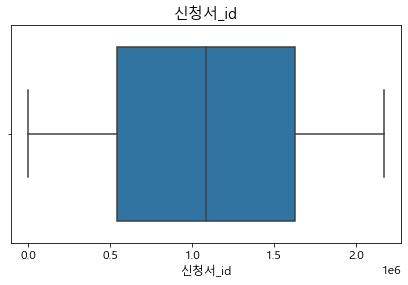

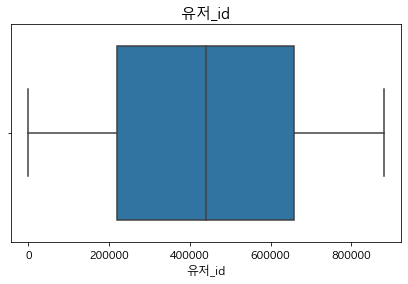

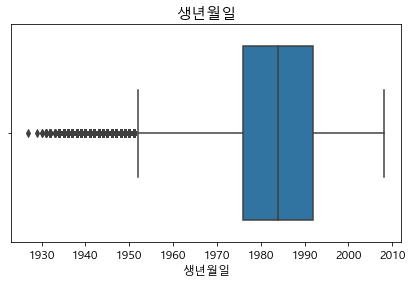

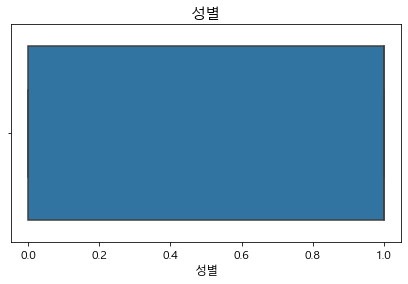

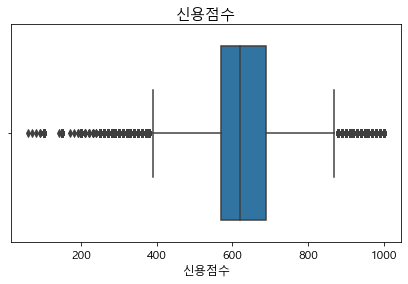

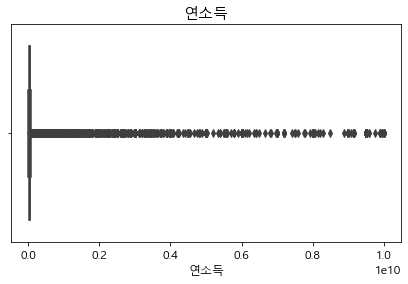

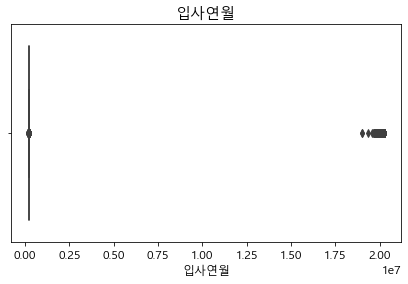

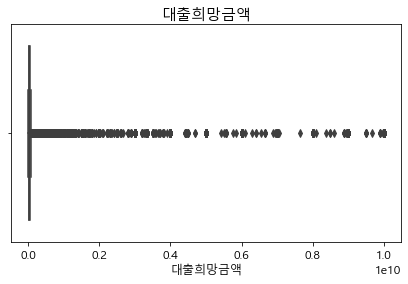

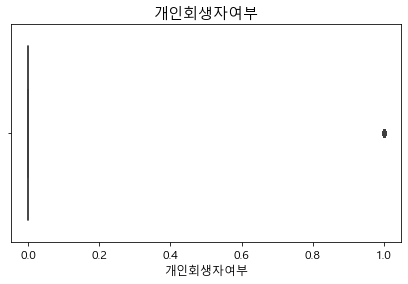

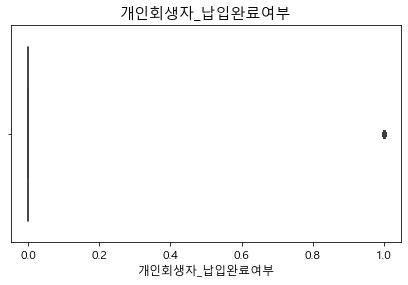

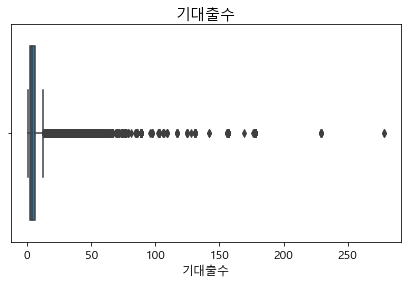

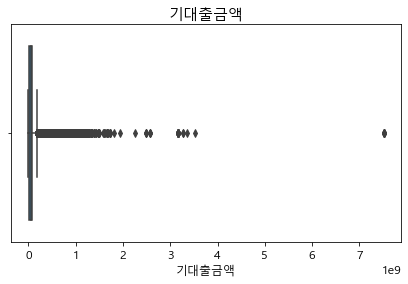

In [198]:
# 가로 그래프
for i in ['신청서_id','유저_id','생년월일','성별','신용점수','연소득'
                ,'입사연월', '대출희망금액','개인회생자여부'
                ,'개인회생자_납입완료여부','기대출수','기대출금액']:
    plt.figure(figsize = (7, 4))
    sns.boxplot(x = i, data = user_df)
    plt.title(i, size = 15)
    plt.show()

In [199]:
user_df['생성일시'] = pd.to_datetime(user_df['생성일시'])

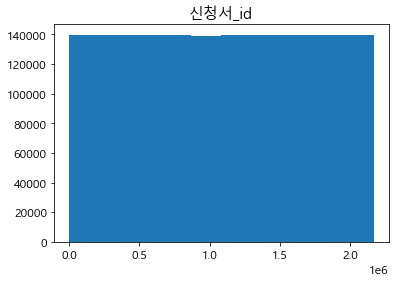

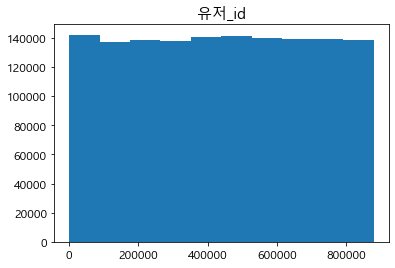

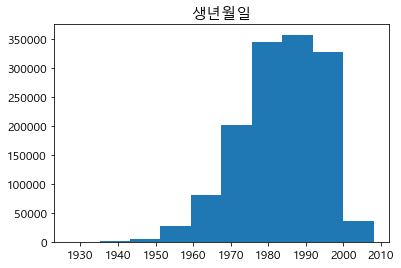

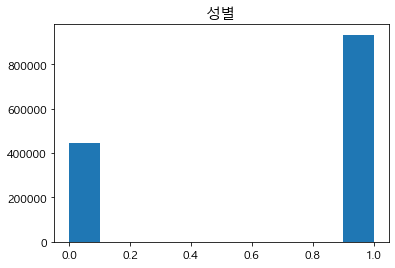

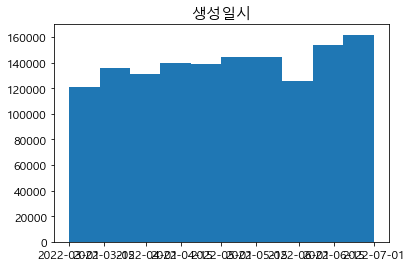

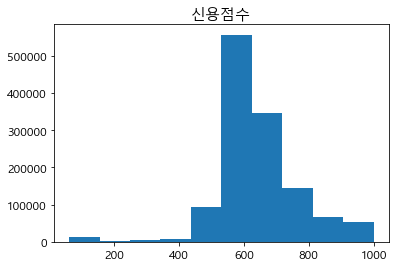

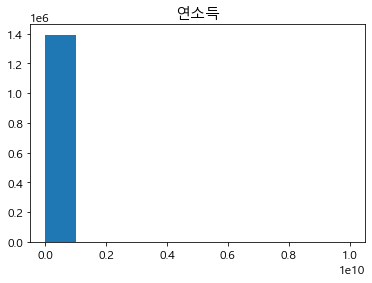

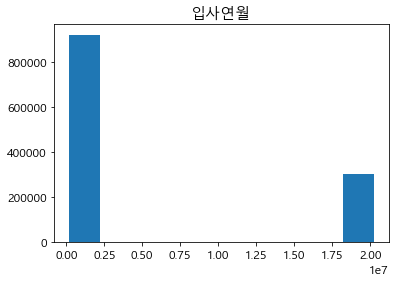

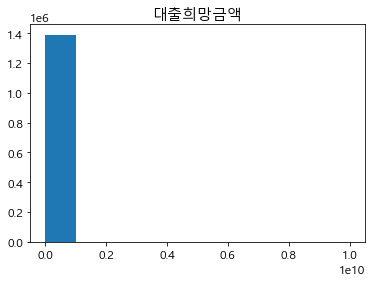

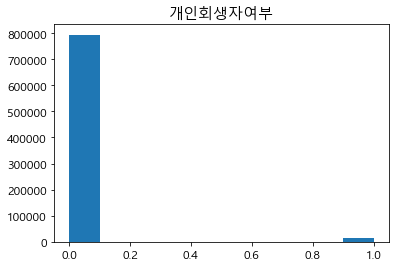

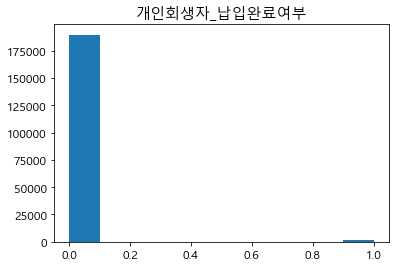

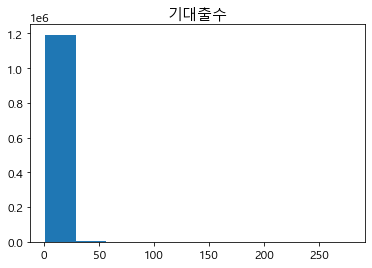

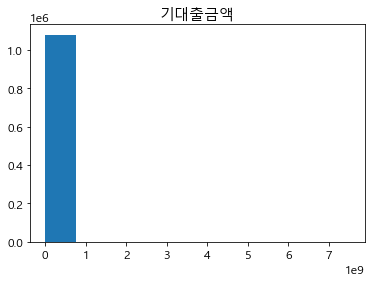

In [200]:
for i in ['신청서_id','유저_id','생년월일','성별','생성일시','신용점수','연소득'
                ,'입사연월','대출희망금액','개인회생자여부'
                ,'개인회생자_납입완료여부','기대출수','기대출금액']:
    plt.hist(user_df[i])
    plt.title(i, size = 15)
    plt.show()

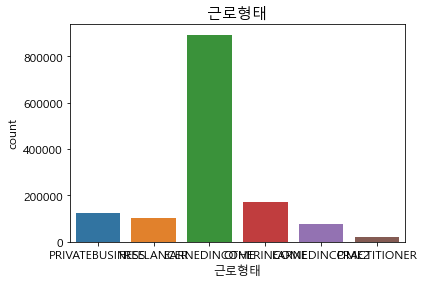

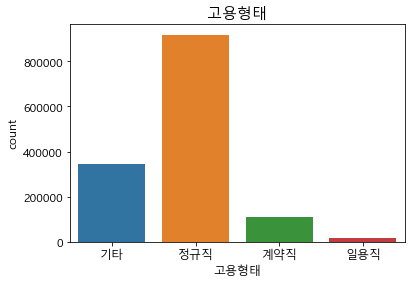

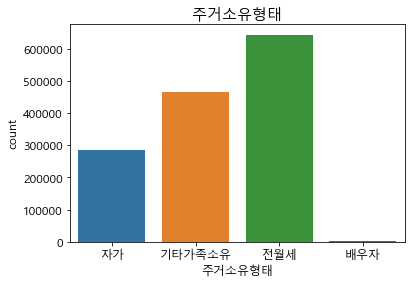

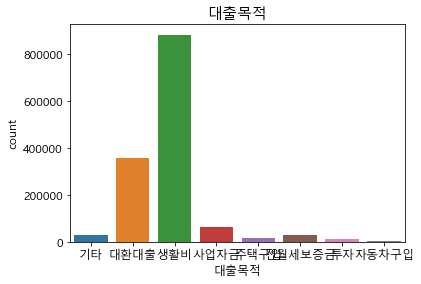

In [201]:
for i in ['근로형태', '고용형태', '주거소유형태', '대출목적']:
    sns.countplot(x=i, data=user_df)
    plt.title(i, size = 15)
    plt.show()

# user_df 각 변수들간의 상관계수 확인하기

<AxesSubplot:>

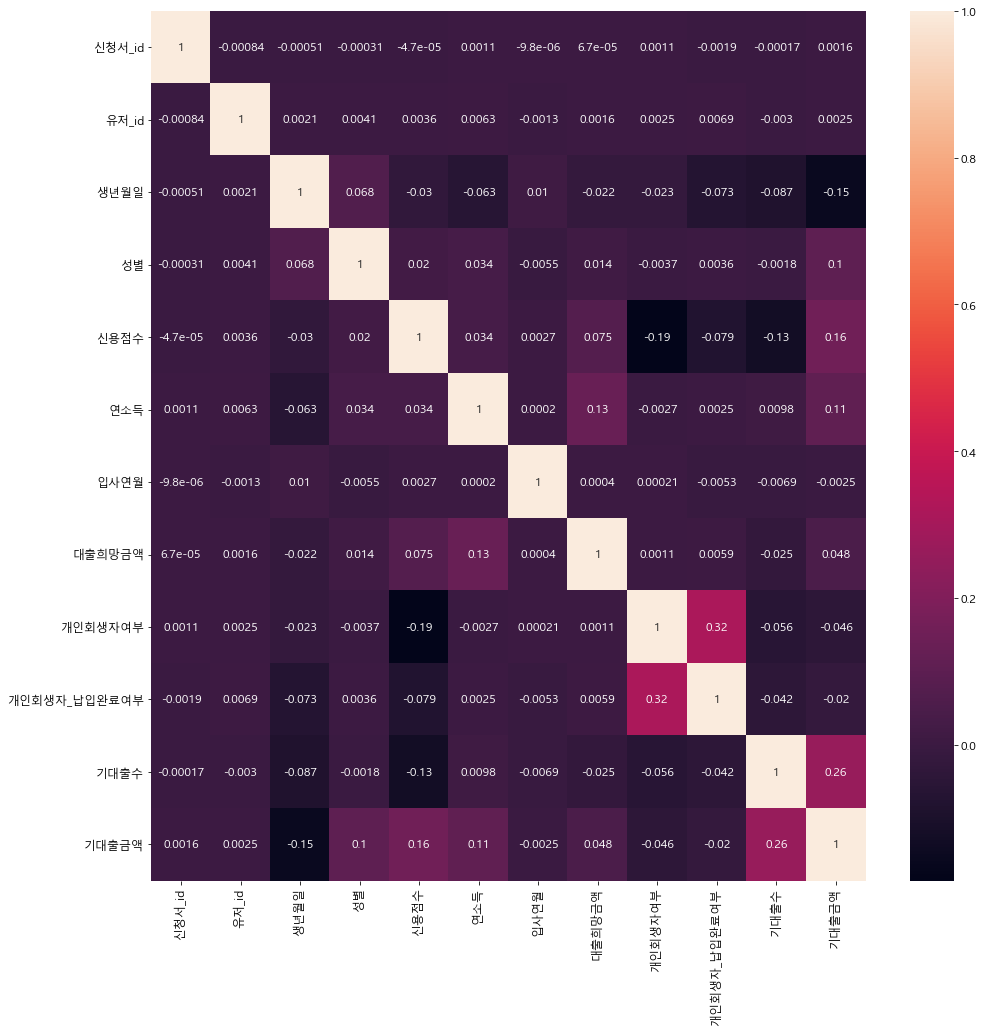

In [202]:
plt.rc('font',size=12)
plt.figure(figsize = (16, 16)) #그림 크기 늘리기
sns.heatmap(user_df.corr(), annot = True) #상관계수 한번에 확인하기
 # annot=True를 써야만 상관계수 수치가 표시 됨

# 결측치가 있는 변수들 보간법을 통해 결측치 채우기

# 연소득이 결측치인 경우

In [203]:
index_na_earnyear=user_df[user_df["연소득"].isnull()].index # 연소득이 결측치인 index
index_notna_earnyear=user_df[user_df["연소득"].notna()].index # 연소득이 결측치가 아닌 index
user_df["유저_id"].loc[index_na_earnyear].value_counts() # 연소득이 결측치인 유저_id

21121     3
827892    3
142003    3
118742    3
177387    2
         ..
128448    1
535742    1
382778    1
550580    1
861363    1
Name: 유저_id, Length: 73, dtype: int64

In [204]:
a=list(user_df["유저_id"][index_notna_earnyear])
b=user_df["유저_id"][index_na_earnyear].isin(a)
b=b.to_frame()
b_index=b[b["유저_id"]==True].index
yearearn_na_list=list(set(list(user_df["유저_id"][b_index].to_frame()["유저_id"]))) 
user_df_na_yearearn=pd.DataFrame(columns=['신청서_id','유저_id','생년월일','성별','생성일시','신용점수','연소득','근로형태'
                ,'입사연월','고용형태','주거소유형태','대출희망금액','대출목적','개인회생자여부'
                ,'개인회생자_납입완료여부','기대출수','기대출금액'])

In [205]:
df_lst = []
for i in yearearn_na_list:
    user_df3=user_df[user_df["유저_id"]==i].sort_values('생성일시')
    user_df3['생성일시'] = pd.to_datetime(user_df3['생성일시']) # 생성일시를 datetime형태로 변형
    user_df3_notna=user_df3[user_df3["연소득"].notna()]
    ##### 보간 법 코드 만들기 #####
    for j in user_df3[user_df3["연소득"].isnull()].index:
        tmp=(user_df3_notna["생성일시"]-user_df3.loc[[j],["생성일시"]].values[0][0]).dt.seconds
        tmp_index=tmp[tmp == min(abs(tmp))].index[0]
        
        user_df3.loc[[j],["연소득"]]=user_df3.loc[tmp_index,"연소득"]
    df_lst.append(user_df3)

In [206]:
user_df_na_yearearn=pd.concat(df_lst)

# 근로형태가 결측치인 경우

In [207]:
index_na_worktype=user_df[user_df["근로형태"].isnull()].index # 근로형태가 결측치인 index
index_notna_worktype=user_df[user_df["근로형태"].notna()].index # 근로형태가 결측치가 아닌 index
user_df["유저_id"].loc[index_na_worktype].value_counts() 

21121     3
142003    3
827892    3
118742    3
177387    2
         ..
737138    1
335426    1
128448    1
535742    1
353476    1
Name: 유저_id, Length: 68, dtype: int64

In [208]:
a=list(user_df["유저_id"][index_notna_worktype])
b=user_df["유저_id"][index_na_worktype].isin(a)
b=b.to_frame()
b_index=b[b["유저_id"]==True].index
worktype_na_list=list(set(list(user_df["유저_id"][b_index].to_frame()["유저_id"]))) 
user_df_na_worktype=pd.DataFrame(columns=['신청서_id','유저_id','생년월일','성별','생성일시','신용점수','연소득','근로형태'
                ,'입사연월','고용형태','주거소유형태','대출희망금액','대출목적','개인회생자여부'
                ,'개인회생자_납입완료여부','기대출수','기대출금액'])

In [209]:
df_lst = []
for i in worktype_na_list:
    user_df3=user_df[user_df["유저_id"]==i].sort_values('생성일시')
    user_df3['생성일시'] = pd.to_datetime(user_df3['생성일시']) # 생성일시를 datetime형태로 변형
    user_df3_notna=user_df3[user_df3["근로형태"].notna()]
    ##### 보간 법 코드 만들기 #####
    for j in user_df3[user_df3["근로형태"].isnull()].index:
        tmp=(user_df3_notna["생성일시"]-user_df3.loc[[j],["생성일시"]].values[0][0]).dt.seconds
        tmp_index=tmp[tmp == min(abs(tmp))].index[0]
        
        user_df3.loc[[j],["근로형태"]]=user_df3.loc[tmp_index,"근로형태"]
    df_lst.append(user_df3)

In [210]:
user_df_na_worktype=pd.concat(df_lst)

# 고용형태가 결측치인 경우

In [211]:
index_na_employmenttype=user_df[user_df["고용형태"].isnull()].index # 고용형태가 결측치인 index
index_notna_employmenttype=user_df[user_df["고용형태"].notna()].index # 고용형태가 결측치가 아닌 index
user_df["유저_id"].loc[index_na_employmenttype].value_counts() 

21121     3
142003    3
827892    3
118742    3
177387    2
         ..
737138    1
335426    1
128448    1
535742    1
353476    1
Name: 유저_id, Length: 68, dtype: int64

In [212]:
a=list(user_df["유저_id"][index_notna_employmenttype])
b=user_df["유저_id"][index_na_employmenttype].isin(a)
b=b.to_frame()
b_index=b[b["유저_id"]==True].index
employmenttype_na_list=list(set(list(user_df["유저_id"][b_index].to_frame()["유저_id"]))) 
user_df_na_employmenttype=pd.DataFrame(columns=['신청서_id','유저_id','생년월일','성별','생성일시','신용점수','연소득','근로형태'
                ,'입사연월','고용형태','주거소유형태','대출희망금액','대출목적','개인회생자여부'
                ,'개인회생자_납입완료여부','기대출수','기대출금액'])

In [213]:
df_lst = []
for i in employmenttype_na_list:
    user_df3=user_df[user_df["유저_id"]==i].sort_values('생성일시')
    user_df3['생성일시'] = pd.to_datetime(user_df3['생성일시']) # 생성일시를 datetime형태로 변형
    user_df3_notna=user_df3[user_df3["고용형태"].notna()]
    ##### 보간 법 코드 만들기 #####
    for j in user_df3[user_df3["고용형태"].isnull()].index:
        tmp=(user_df3_notna["생성일시"]-user_df3.loc[[j],["생성일시"]].values[0][0]).dt.seconds
        tmp_index=tmp[tmp == min(abs(tmp))].index[0]
        
        user_df3.loc[[j],["고용형태"]]=user_df3.loc[tmp_index,"고용형태"]
    df_lst.append(user_df3)

In [214]:
user_df_na_employmenttype=pd.concat(df_lst)

# 주거소유형태가 결측치인 경우

In [215]:
index_na_residencetype=user_df[user_df["주거소유형태"].isnull()].index # 주거소유형태가 결측치인 index
index_notna_residencetype=user_df[user_df["주거소유형태"].notna()].index # 주거소유형태가 결측치가 아닌 index
user_df["유저_id"].loc[index_na_residencetype].value_counts() 

21121     3
142003    3
827892    3
118742    3
177387    2
         ..
737138    1
335426    1
128448    1
535742    1
353476    1
Name: 유저_id, Length: 68, dtype: int64

In [216]:
a=list(user_df["유저_id"][index_notna_residencetype])
b=user_df["유저_id"][index_na_residencetype].isin(a)
b=b.to_frame()
b_index=b[b["유저_id"]==True].index
residencetype_na_list=list(set(list(user_df["유저_id"][b_index].to_frame()["유저_id"]))) 
user_df_na_residencetype=pd.DataFrame(columns=['신청서_id','유저_id','생년월일','성별','생성일시','신용점수','연소득','근로형태'
                ,'입사연월','고용형태','주거소유형태','대출희망금액','대출목적','개인회생자여부'
                ,'개인회생자_납입완료여부','기대출수','기대출금액'])

In [217]:
df_lst = []
for i in residencetype_na_list:
    user_df3=user_df[user_df["유저_id"]==i].sort_values('생성일시')
    user_df3['생성일시'] = pd.to_datetime(user_df3['생성일시']) # 생성일시를 datetime형태로 변형
    user_df3_notna=user_df3[user_df3["주거소유형태"].notna()]
    ##### 보간 법 코드 만들기 #####
    for j in user_df3[user_df3["주거소유형태"].isnull()].index:
        tmp=(user_df3_notna["생성일시"]-user_df3.loc[[j],["생성일시"]].values[0][0]).dt.seconds
        tmp_index=tmp[tmp == min(abs(tmp))].index[0]
        
        user_df3.loc[[j],["주거소유형태"]]=user_df3.loc[tmp_index,"주거소유형태"]
    df_lst.append(user_df3)

In [218]:
user_df_na_residencetype=pd.concat(df_lst)

# 대출희망금액이 결측치인 경우

In [219]:
index_na_loanamount=user_df[user_df["대출희망금액"].isnull()].index # 대출희망금액이 결측치인 index
index_notna_loanamount=user_df[user_df["대출희망금액"].notna()].index # 대출희망금액이 결측치가 아닌 index
user_df["유저_id"].loc[index_na_loanamount].value_counts() # 

21121     3
142003    3
827892    3
118742    3
177387    2
         ..
737138    1
335426    1
128448    1
535742    1
353476    1
Name: 유저_id, Length: 68, dtype: int64

In [220]:
a=list(user_df["유저_id"][index_notna_loanamount])
b=user_df["유저_id"][index_na_loanamount].isin(a)
b=b.to_frame()
b_index=b[b["유저_id"]==True].index
loanamount_na_list=list(set(list(user_df["유저_id"][b_index].to_frame()["유저_id"]))) 
user_df_na_loanamount=pd.DataFrame(columns=['신청서_id','유저_id','생년월일','성별','생성일시','신용점수','연소득','근로형태'
                ,'입사연월','고용형태','주거소유형태','대출희망금액','대출목적','개인회생자여부'
                ,'개인회생자_납입완료여부','기대출수','기대출금액'])

In [221]:
df_lst = []
for i in loanamount_na_list:
    user_df3=user_df[user_df["유저_id"]==i].sort_values('생성일시')
    user_df3['생성일시'] = pd.to_datetime(user_df3['생성일시']) # 생성일시를 datetime형태로 변형
    user_df3_notna=user_df3[user_df3["대출희망금액"].notna()]
    ##### 보간 법 코드 만들기 #####
    for j in user_df3[user_df3["대출희망금액"].isnull()].index:
        tmp=(user_df3_notna["생성일시"]-user_df3.loc[[j],["생성일시"]].values[0][0]).dt.seconds
        tmp_index=tmp[tmp == min(abs(tmp))].index[0]
        
        user_df3.loc[[j],["대출희망금액"]]=user_df3.loc[tmp_index,"대출희망금액"]
    df_lst.append(user_df3)

In [222]:
user_df_na_loanamount=pd.concat(df_lst)

# 대출목적이 결측치인 경우

In [223]:
index_na_loanpurpose=user_df[user_df["대출목적"].isnull()].index # 대출목적이 결측치인 index
index_notna_loanpurpose=user_df[user_df["대출목적"].notna()].index # 대출목적이 결측치가 아닌 index
user_df["유저_id"].loc[index_na_loanpurpose].value_counts() # 

21121     3
142003    3
827892    3
118742    3
177387    2
         ..
737138    1
335426    1
128448    1
535742    1
353476    1
Name: 유저_id, Length: 68, dtype: int64

In [224]:
a=list(user_df["유저_id"][index_notna_loanpurpose])
b=user_df["유저_id"][index_na_loanpurpose].isin(a)
b=b.to_frame()
b_index=b[b["유저_id"]==True].index
loanpurpose_na_list=list(set(list(user_df["유저_id"][b_index].to_frame()["유저_id"]))) 
user_df_na_loanpurpose=pd.DataFrame(columns=['신청서_id','유저_id','생년월일','성별','생성일시','신용점수','연소득','근로형태'
                ,'입사연월','고용형태','주거소유형태','대출희망금액','대출목적','개인회생자여부'
                ,'개인회생자_납입완료여부','기대출수','기대출금액'])

In [225]:
df_lst = []
for i in loanpurpose_na_list:
    user_df3=user_df[user_df["유저_id"]==i].sort_values('생성일시')
    user_df3['생성일시'] = pd.to_datetime(user_df3['생성일시']) # 생성일시를 datetime형태로 변형
    user_df3_notna=user_df3[user_df3["대출목적"].notna()]
    ##### 보간 법 코드 만들기 #####
    for j in user_df3[user_df3["대출목적"].isnull()].index:
        tmp=(user_df3_notna["생성일시"]-user_df3.loc[[j],["생성일시"]].values[0][0]).dt.seconds
        tmp_index=tmp[tmp == min(abs(tmp))].index[0]
        
        user_df3.loc[[j],["대출목적"]]=user_df3.loc[tmp_index,"대출목적"]
    df_lst.append(user_df3)

In [226]:
user_df_na_loanpurpose=pd.concat(df_lst)

# 신용점수가 결측치인 경우

In [227]:
index_na_creditscore=user_df[user_df["신용점수"].isnull()].index # 신용점수가 결측치인 index
index_notna_creditscore=user_df[user_df["신용점수"].notna()].index # 신용점수가 결측치가 아닌 index
user_df["유저_id"].loc[index_na_creditscore].value_counts()  

259924    38
51845     34
564140    33
82371     32
75322     30
          ..
58491      1
169077     1
566387     1
441456     1
2049       1
Name: 유저_id, Length: 74632, dtype: int64

In [228]:
a=list(user_df["유저_id"][index_notna_creditscore])
b=user_df["유저_id"][index_na_creditscore].isin(a)
b=b.to_frame()
b_index=b[b["유저_id"]==True].index
creditscore_na_list=list(set(list(user_df["유저_id"][b_index].to_frame()["유저_id"]))) 
user_df_na_creditscore=pd.DataFrame(columns=['신청서_id','유저_id','생년월일','성별','생성일시','신용점수','연소득','근로형태'
                ,'입사연월','고용형태','주거소유형태','대출희망금액','대출목적','개인회생자여부'
                ,'개인회생자_납입완료여부','기대출수','기대출금액'])

In [229]:
df_lst = []
for i in creditscore_na_list:
    user_df3=user_df[user_df["유저_id"]==i].sort_values('생성일시')
    user_df3['생성일시'] = pd.to_datetime(user_df3['생성일시']) # 생성일시를 datetime형태로 변형
    user_df3_notna=user_df3[user_df3["신용점수"].notna()]
    ##### 보간 법 코드 만들기 #####
    for j in user_df3[user_df3["신용점수"].isnull()].index:
        tmp=(user_df3_notna["생성일시"]-user_df3.loc[[j],["생성일시"]].values[0][0]).dt.seconds
        tmp_index=tmp[tmp == min(abs(tmp))].index[0]
        
        user_df3.loc[[j],["신용점수"]]=user_df3.loc[tmp_index,"신용점수"]
    df_lst.append(user_df3)

In [230]:
user_df_na_creditscore=pd.concat(df_lst)

# 입사연월이 결측치인 경우

## 근로형태가 OTHERINCOME이면 입사연월은 입력할 수 없으므로 209912를 지정

In [ ]:
user_df2=user_df.copy()
user_df2[user_df2["근로형태"]=='OTHERINCOME'].index
for i in user_df2[user_df2["근로형태"]=='OTHERINCOME'].index:
    user_df2.loc[i,"입사연월"]=20991201 # 2099년 12월01일

In [ ]:
index_na_employmentyear=user_df[user_df["입사연월"].isna()==True].index&user_df[user_df["근로형태"]!='OTHERINCOME'].index # 입사연월이 결측치인 index
index_notna_employmentyear=user_df[user_df["입사연월"].notna()].index # 입사연월이 결측치가 아닌 index
user_df["유저_id"].loc[index_na_employmentyear].value_counts() # 

In [ ]:
a=list(user_df["유저_id"][index_notna_employmentyear])
b=user_df["유저_id"][index_na_employmentyear].isin(a)
b=b.to_frame()
b_index=b[b["유저_id"]==True].index
employmentyear_na_list=list(set(list(user_df["유저_id"][b_index].to_frame()["유저_id"]))) 
user_df_na_employmentyear=pd.DataFrame(columns=['신청서_id','유저_id','생년월일','성별','생성일시','신용점수','연소득','근로형태'
                ,'입사연월','고용형태','주거소유형태','대출희망금액','대출목적','개인회생자여부'
                ,'개인회생자_납입완료여부','기대출수','기대출금액'])

In [ ]:
df_lst = []
for i in employmentyear_na_list:
    user_df3=user_df[user_df["유저_id"]==i].sort_values('생성일시')
    user_df3['생성일시'] = pd.to_datetime(user_df3['생성일시']) # 생성일시를 datetime형태로 변형
    user_df3_notna=user_df3[user_df3["입사연월"].notna()]
    ##### 보간 법 코드 만들기 #####
    for j in user_df3[user_df3["입사연월"].isnull()].index:
        tmp=(user_df3_notna["생성일시"]-user_df3.loc[[j],["생성일시"]].values[0][0]).dt.seconds
        tmp_index=tmp[tmp == min(abs(tmp))].index[0]
        
        user_df3.loc[[j],["입사연월"]]=user_df3.loc[tmp_index,"입사연월"]
    df_lst.append(user_df3)

In [ ]:
user_df_na_employmentyear=pd.concat(df_lst)

# 보간법으로 결측치를 채운 데이터 user_df에 적용하기

In [ ]:
yearearn_index=user_df_na_yearearn.index
worktype_index=user_df_na_worktype.index
employmenttype_index=user_df_na_employmenttype.index
residencetype_index=user_df_na_residencetype.index
loanamount_index=user_df_na_loanamount.index
loanpurpose_index=user_df_na_loanpurpose.index
creditscore_index=user_df_na_creditscore.index

In [ ]:
for i in yearearn_index:
    user_df["연소득"][i]=user_df_na_yearearn["연소득"][i]
user_df.isnull().sum()

In [ ]:
for i in worktype_index:
    user_df["근로형태"][i]=user_df_na_worktype["근로형태"][i]
user_df.isnull().sum()

In [ ]:
for i in employmenttype_index:
    user_df["고용형태"][i]=user_df_na_employmenttype["고용형태"][i]
user_df.isnull().sum()

In [ ]:
for i in residencetype_index:
    user_df["주거소유형태"][i]=user_df_na_residencetype["주거소유형태"][i]
user_df.isnull().sum()

In [ ]:
for i in loanamount_index:
    user_df["대출희망금액"][i]=user_df_na_loanamount["대출희망금액"][i]
user_df.isnull().sum()

In [ ]:
for i in loanpurpose_index:
    user_df["대출목적"][i]=user_df_na_loanpurpose["대출목적"][i]
user_df.isnull().sum()

In [ ]:
for i in creditscore_index:
    user_df["신용점수"][i]=user_df_na_creditscore["신용점수"][i]
user_df.isnull().sum()

In [ ]:
for i in user_df_na_employmentyear.index:
    user_df2["입사연월"][i]=user_df_na_employmentyear["입사연월"][i]
user_df.isnull().sum()

In [ ]:
user_df2.isnull().sum()

# 파생변수 생성

# 신용점수를 이용하여 신용등급 변수 만들기

In [ ]:
user_df2["신용등급"]=np.nan
for i in range(len(user_df2)):
    if (942<=user_df2["신용점수"][i]<=1000):
        user_df2["신용등급"][i]="1등급"
    elif (891<=user_df2["신용점수"][i]<942):
        user_df2["신용등급"][i]="2등급"
    elif (832<=user_df2["신용점수"][i]<891):
        user_df2["신용등급"][i]="3등급"
    elif (768<=user_df2["신용점수"][i]<832):
        user_df2["신용등급"][i]="4등급"
    elif (698<=user_df2["신용점수"][i]<768):
        user_df2["신용등급"][i]="5등급"
    elif (630<=user_df2["신용점수"][i]<698):
        user_df2["신용등급"][i]="6등급"
    elif (530<=user_df2["신용점수"][i]<630):
        user_df2["신용등급"][i]="7등급"
    elif (454<=user_df2["신용점수"][i]<530):
        user_df2["신용등급"][i]="8등급"
    elif (335<=user_df2["신용점수"][i]<454):
        user_df9["신용등급"][i]="9등급"
    elif (0<=user_df2["신용점수"][i]<335):
        user_df2["신용등급"][i]="10등급"
    else:
        user_df2["신용등급"][i]="모름"

# 신용등급을 이용하여 신용군 변수 만들기

In [ ]:
user_df2["신용군"]=np.nan
for i in range(len(user_df2)):
    if (user_df2["신용등급"][i]=="1등급"):
        user_df2["신용군"][i]="우량군"
    elif (user_df2["신용등급"][i]=="2등급"):
        user_df2["신용군"][i]="우량군"
    elif (user_df2["신용등급"][i]=="3등급"):
        user_df2["신용군"][i]="일반군"
    elif (user_df2["신용등급"][i]=="4등급"):
        user_df2["신용군"][i]="일반군"
    elif (user_df2["신용등급"][i]=="5등급"):
        user_df2["신용군"][i]="일반군"
    elif (user_df2["신용등급"][i]=="6등급"):
        user_df2["신용군"][i]="일반군"
    elif (user_df2["신용등급"][i]=="7등급"):
        user_df2["신용군"][i]="주의군"
    elif (user_df2["신용등급"][i]=="8등급"):
        user_df2["신용군"][i]="주의군"
    elif (user_df2["신용등급"][i]=="9등급"):
        user_df2["신용군"][i]="위험군"
    elif (user_df2["신용등급"][i]=="10등급"):
        user_df2["신용군"][i]="위험군"
    else:
        user_df2["신용군"][i]="모름"

# 생년월일을 이용하여 나이 변수 만들기

In [ ]:
user_df2["나이"]=np.nan
for i in range(len(user_df2)):
    user_df2["나이"][i]=(2022-user_df2["생년월일"][i])

# 나이를 이용하여 연령대 변수 만들기

In [ ]:
user_df2["연령대"]=np.nan
for i in range(len(user_df2)):
    if user_df2["나이"][i]<20:
        user_df2["연령대"][i]="10대이하"
    elif 20<=user_df2["나이"][i]<30:
        user_df2["연령대"][i]="20대"
    elif 30<=user_df2["나이"][i]<40:
        user_df2["연령대"][i]="30대"
    elif 40<=user_df2["나이"][i]<50:
        user_df2["연령대"][i]="40대"
    elif 50<=user_df2["나이"][i]<60:
        user_df2["연령대"][i]="50대"
    elif 60<=user_df2["나이"][i]<70:
        user_df2["연령대"][i]="60대"
    elif 70<=user_df2["나이"][i]<150:
        user_df2["연령대"][i]="70대이상"
    else:
        user_df2["연령대"][i]="모름"

# 개인회생 변수 만들기
## 개인회생자여부=0  =>0
## 개인회생자여부=1, 납입완료여부 납입0  =>1
## 개인회생자여부=1, 납입완료여부 납입1  =>2
## 개인회생자여부=NA면 납인완료여부도 NA=>NA

In [ ]:
user_df2["개인회생"]=np.nan
Rehabilitation_NA_index=user_df2[user_df2["개인회생자여부"].isnull()].index 
Rehabilitation_0_index=user_df2[user_df2["개인회생자여부"]==0].index
Rehabilitation_1_Payment_0_index=user_df2[user_df2["개인회생자여부"]==1].index&user_df2[user_df2["개인회생자_납입완료여부"]==0].index
Rehabilitation_1_Payment_1_index=user_df2[user_df2["개인회생자여부"]==1].index&user_df2[user_df2["개인회생자_납입완료여부"]==1].index

In [ ]:
user_df2["개인회생"].loc[Rehabilitation_NA_index]=np.nan
user_df2["개인회생"].loc[Rehabilitation_0_index]=0
user_df2["개인회생"].loc[Rehabilitation_1_Payment_0_index]=1
user_df2["개인회생"].loc[Rehabilitation_1_Payment_1_index]=2

# 기대출수유무 변수 생성
## 기대출수유무 NA=>0
## 기대출수유무 not NA=>1

In [ ]:
user_df2["기대출수유무"]=np.nan
loan_number_NA_index=user_df2[user_df2["기대출수"].isna()].index
loan_number_NOTNA_index=user_df2[user_df2["기대출수"].isna()==False].index

In [ ]:
user_df2["기대출수유무"].loc[loan_number_NA_index]=0
user_df2["기대출수유무"].loc[loan_number_NOTNA_index]=1

# 문자형 변수들 숫자형 변수로 변형

# 신용등급 변수에 int형 값 지정해주기

In [ ]:
user_df2.loc[user_df2['신용등급']=='1등급','신용등급']=1
user_df2.loc[user_df2['신용등급']=='2등급','신용등급']=2
user_df2.loc[user_df2['신용등급']=='3등급','신용등급']=3
user_df2.loc[user_df2['신용등급']=='4등급','신용등급']=4
user_df2.loc[user_df2['신용등급']=='5등급','신용등급']=5
user_df2.loc[user_df2['신용등급']=='6등급','신용등급']=6
user_df2.loc[user_df2['신용등급']=='7등급','신용등급']=7
user_df2.loc[user_df2['신용등급']=='8등급','신용등급']=8
user_df2.loc[user_df2['신용등급']=='9등급','신용등급']=9
user_df2.loc[user_df2['신용등급']=='10등급','신용등급']=10
user_df2.loc[user_df2['신용등급']=='모름','신용등급']=np.nan

# 신용균 변수에 int형 값 지정해주기

In [ ]:
user_df2.loc[user_df2['신용군']=='우량군','신용군']=1
user_df2.loc[user_df2['신용군']=='일반군','신용군']=2
user_df2.loc[user_df2['신용군']=='주의군','신용군']=3
user_df2.loc[user_df2['신용군']=='위험군','신용군']=4
user_df2.loc[user_df2['신용군']=='모름','신용군']=np.nan

# 연령대 변수에 int형 값 지정해주기

In [ ]:
user_df2.loc[user_df2['연령대']=='10대이하','연령대']=1
user_df2.loc[user_df2['연령대']=='20대','연령대']=2
user_df2.loc[user_df2['연령대']=='30대','연령대']=3
user_df2.loc[user_df2['연령대']=='40대','연령대']=4
user_df2.loc[user_df2['연령대']=='50대','연령대']=5
user_df2.loc[user_df2['연령대']=='60대','연령대']=6
user_df2.loc[user_df2['연령대']=='70대이상','연령대']=7
user_df2.loc[user_df2['연령대']=='모름','연령대']=np.nan

# 근로형태 변수에 int형 값 지정해주기

In [ ]:
EARNEDINCOME_index=user_df2[user_df2["근로형태"]=='EARNEDINCOME'].index
OTHERINCOME_index=user_df2[user_df2["근로형태"]=='OTHERINCOME'].index
PRIVATEBUSINESS_index=user_df2[user_df2["근로형태"]=='PRIVATEBUSINESS'].index
FREELANCER_index=user_df2[user_df2["근로형태"]=='FREELANCER'].index
EARNEDINCOME2_index=user_df2[user_df2["근로형태"]=='EARNEDINCOME2'].index
PRACTITIONER_index=user_df2[user_df2["근로형태"]=='PRACTITIONER'].index
user_df2["근로형태"].loc[EARNEDINCOME_index]=0
user_df2["근로형태"].loc[OTHERINCOME_index]=1
user_df2["근로형태"].loc[PRIVATEBUSINESS_index]=2
user_df2["근로형태"].loc[FREELANCER_index]=3
user_df2["근로형태"].loc[EARNEDINCOME2_index]=4
user_df2["근로형태"].loc[PRACTITIONER_index]=5
user_df2["근로형태"].value_counts()

# 고용형태 변수에 int형 값 지정해주기

In [ ]:
regular_index=user_df2[user_df2["고용형태"]=='정규직'].index # 정규직
etc_index=user_df2[user_df2["고용형태"]=='기타'].index
contract_index=user_df2[user_df2["고용형태"]=='계약직'].index
daily_index=user_df2[user_df2["고용형태"]=='일용직'].index
user_df2["고용형태"].loc[regular_index]=0
user_df2["고용형태"].loc[etc_index]=1
user_df2["고용형태"].loc[contract_index]=2
user_df2["고용형태"].loc[daily_index]=3
user_df2["고용형태"].value_counts()

# 주거소유형태 변수에 int형 값 지정해주기

In [ ]:
monthly_index=user_df2[user_df2["주거소유형태"]=='전월세'].index 
otherfamily_index=user_df2[user_df2["주거소유형태"]=='기타가족소유'].index
self_index=user_df2[user_df2["주거소유형태"]=='자가'].index
spouse_index=user_df2[user_df2["주거소유형태"]=='배우자'].index
user_df2["주거소유형태"].loc[monthly_index]=0
user_df2["주거소유형태"].loc[otherfamily_index]=1
user_df2["주거소유형태"].loc[self_index]=2
user_df2["주거소유형태"].loc[spouse_index]=3
user_df2["주거소유형태"].value_counts()

# 대출목적 변수에 int형 값 지정해주기

In [ ]:
living_index=user_df2[user_df2["대출목적"]=='생활비'].index 
switchloan_index=user_df2[user_df2["대출목적"]=='대환대출'].index
business_index=user_df2[user_df2["대출목적"]=='사업자금'].index
etc_index=user_df2[user_df2["대출목적"]=='기타'].index
housedeposit_index=user_df2[user_df2["대출목적"]=='전월세보증금'].index
buyhouse_index=user_df2[user_df2["대출목적"]=='주택구입'].index
invest_index=user_df2[user_df2["대출목적"]=='투자'].index
buycar_index=user_df2[user_df2["대출목적"]=='자동차구입'].index
user_df2["대출목적"].loc[living_index]=0
user_df2["대출목적"].loc[switchloan_index]=1
user_df2["대출목적"].loc[business_index]=2
user_df2["대출목적"].loc[etc_index]=3
user_df2["대출목적"].loc[housedeposit_index]=4
user_df2["대출목적"].loc[buyhouse_index]=5
user_df2["대출목적"].loc[invest_index]=6
user_df2["대출목적"].loc[buycar_index]=7
user_df2["대출목적"].value_counts()

In [ ]:
user_df2=user_df2.astype({'신용등급':'float'})
user_df2=user_df2.astype({'신용군':'float'})
user_df2=user_df2.astype({'연령대':'float'})
user_df2=user_df2.astype({'근로형태':'float'})
user_df2=user_df2.astype({'고용형태':'float'})
user_df2=user_df2.astype({'주거소유형태':'float'})
user_df2=user_df2.astype({'대출목적':'float'})

# missforest모델을 이용해서 모든 변수들의 결측치 채우기

In [ ]:
user_df3=user_df2[['신청서_id', '유저_id', '생년월일', '성별', '신용점수', '연소득', '근로형태', '입사연월',
       '고용형태', '주거소유형태', '대출희망금액', '대출목적', '개인회생자여부', '개인회생자_납입완료여부', '기대출수',
       '기대출금액', '신용등급', '신용군', '나이', '연령대', '개인회생', '기대출수유무']].copy()

In [ ]:
pip install missingpy

In [ ]:
from missingpy import MissForest

In [ ]:
user_df3.info()

In [ ]:
from missingpy import MissForest
user_df3_cols = user_df3.columns.tolist()

imputer = MissForest(random_state=42)

user_df3_imputed = imputer.fit_transform(user_df3)

user_df3 = pd.DataFrame(user_df3_imputed, columns=user_df3_cols)

In [ ]:
user_df3.isnull().sum()

# 성별, 근로형태, 고용형태, 주거소유형태, 대출목적, 신용등급 변수 값을 정수 형태로 맞춰주기 위해 반올림 진행

In [ ]:
index1=user_df3[user_df3["성별"]>=0.5].index
index2=user_df3[user_df3["성별"]<0.5].index
user_df3["성별"].loc[index1]=1
user_df3["성별"].loc[index2]=0
user_df3["성별"].value_counts()

In [ ]:
index3=user_df3[user_df3["근로형태"]<0.5].index
index4=user_df3[user_df3["근로형태"]>=0.5].index&user_df3[user_df3["근로형태"]<1.5].index
index5=user_df3[user_df3["근로형태"]>=1.5].index&user_df3[user_df3["근로형태"]<2.5].index
index6=user_df3[user_df3["근로형태"]>=2.5].index&user_df3[user_df3["근로형태"]<3.5].index
index7=user_df3[user_df3["근로형태"]>=3.5].index&user_df3[user_df3["근로형태"]<4.5].index
index8=user_df3[user_df3["근로형태"]>=4.5].index&user_df3[user_df3["근로형태"]<5.5].index
user_df3["근로형태"].loc[index3]=0
user_df3["근로형태"].loc[index4]=1
user_df3["근로형태"].loc[index5]=2
user_df3["근로형태"].loc[index6]=3
user_df3["근로형태"].loc[index7]=4
user_df3["근로형태"].loc[index8]=5
user_df3["근로형태"].value_counts()

In [ ]:
index9=user_df3[user_df3["고용형태"]<0.5].index
index10=user_df3[user_df3["고용형태"]>=0.5].index&user_df3[user_df3["고용형태"]<1.5].index
index11=user_df3[user_df3["고용형태"]>=1.5].index&user_df3[user_df3["고용형태"]<2.5].index
index12=user_df3[user_df3["고용형태"]>=2.5].index&user_df3[user_df3["고용형태"]<3.5].index
user_df3["고용형태"].loc[index9]=0
user_df3["고용형태"].loc[index10]=1
user_df3["고용형태"].loc[index11]=2
user_df3["고용형태"].loc[index12]=3
user_df3["고용형태"].value_counts()

In [ ]:
index13=user_df3[user_df3["주거소유형태"]<0.5].index
index14=user_df3[user_df3["주거소유형태"]>=0.5].index&user_df3[user_df3["주거소유형태"]<1.5].index
index15=user_df3[user_df3["주거소유형태"]>=1.5].index&user_df3[user_df3["주거소유형태"]<2.5].index
index16=user_df3[user_df3["주거소유형태"]>=2.5].index&user_df3[user_df3["주거소유형태"]<3.5].index
user_df3["주거소유형태"].loc[index13]=0
user_df3["주거소유형태"].loc[index14]=1
user_df3["주거소유형태"].loc[index15]=2
user_df3["주거소유형태"].loc[index16]=3
user_df3["주거소유형태"].value_counts()

In [ ]:
index17=user_df3[user_df3["대출목적"]<0.5].index
index18=user_df3[user_df3["대출목적"]>=0.5].index&user_df3[user_df3["대출목적"]<1.5].index
index19=user_df3[user_df3["대출목적"]>=1.5].index&user_df3[user_df3["대출목적"]<2.5].index
index20=user_df3[user_df3["대출목적"]>=2.5].index&user_df3[user_df3["대출목적"]<3.5].index
index21=user_df3[user_df3["대출목적"]>=3.5].index&user_df3[user_df3["대출목적"]<4.5].index
index22=user_df3[user_df3["대출목적"]>=4.5].index&user_df3[user_df3["대출목적"]<5.5].index
index23=user_df3[user_df3["대출목적"]>=5.5].index&user_df3[user_df3["대출목적"]<6.5].index
index24=user_df3[user_df3["대출목적"]>=6.5].index&user_df3[user_df3["대출목적"]<7.5].index
user_df3["대출목적"].loc[index17]=0
user_df3["대출목적"].loc[index18]=1
user_df3["대출목적"].loc[index19]=2
user_df3["대출목적"].loc[index20]=3
user_df3["대출목적"].loc[index21]=4
user_df3["대출목적"].loc[index22]=5
user_df3["대출목적"].loc[index23]=6
user_df3["대출목적"].loc[index24]=7
user_df3["대출목적"].value_counts()

In [ ]:
index25=user_df3[user_df3["신용등급"]<1.5].index
index26=user_df3[user_df3["신용등급"]>=1.5].index&user_df3[user_df3["신용등급"]<2.5].index
index27=user_df3[user_df3["신용등급"]>=2.5].index&user_df3[user_df3["신용등급"]<3.5].index
index28=user_df3[user_df3["신용등급"]>=3.5].index&user_df3[user_df3["신용등급"]<4.5].index
index29=user_df3[user_df3["신용등급"]>=4.5].index&user_df3[user_df3["신용등급"]<5.5].index
index30=user_df3[user_df3["신용등급"]>=5.5].index&user_df3[user_df3["신용등급"]<6.5].index
index31=user_df3[user_df3["신용등급"]>=6.5].index&user_df3[user_df3["신용등급"]<7.5].index
index32=user_df3[user_df3["신용등급"]>=7.5].index&user_df3[user_df3["신용등급"]<8.5].index
index33=user_df3[user_df3["신용등급"]>=8.5].index&user_df3[user_df3["신용등급"]<9.5].index
index34=user_df3[user_df3["신용등급"]>=9.5].index&user_df3[user_df3["신용등급"]<10.5].index
user_df3["신용등급"].loc[index25]=1
user_df3["신용등급"].loc[index26]=2
user_df3["신용등급"].loc[index27]=3
user_df3["신용등급"].loc[index28]=4
user_df3["신용등급"].loc[index29]=5
user_df3["신용등급"].loc[index30]=6
user_df3["신용등급"].loc[index31]=7
user_df3["신용등급"].loc[index32]=8
user_df3["신용등급"].loc[index33]=9
user_df3["신용등급"].loc[index34]=10
user_df3["신용등급"].value_counts()

# user_df3 데이터와 loan_df 데이터 병합하기

In [ ]:
loan_df2=pd.merge(loan_df,user_df3, on='신청서_id', how='left')

In [ ]:
loan_df2.isnull().sum()

In [ ]:
plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False
plt.rc('font',size=12)
plt.figure(figsize = (16, 16)) #그림 크기 늘리기
sns.heatmap(loan_df2.corr(), annot = True) #상관계수 한번에 확인하기
 # annot=True를 써야만 상관계수 수치가 표시 됨

# 승인한도와 승인금리 결측치를 해당 행의 신용등급의 평균 승인한도 승인금리로 채워주기

In [ ]:
loan_index=loan_df2[loan_df2["승인한도"].isnull()].index
loan_na=loan_df2[loan_df2["승인한도"].isnull()]

In [ ]:
for i in (loan_df2.loc[loan_index,"신용등급"].unique()):
    loan_na.loc[loan_na[loan_na["신용등급"]==i].index,'승인금리']=loan_df2.loc[loan_df2[loan_df2["신용등급"]==i].index,'승인금리'].mean()
    loan_na.loc[loan_na[loan_na["신용등급"]==i].index,'승인한도']=loan_df2.loc[loan_df2[loan_df2["신용등급"]==i].index,'승인한도'].mean()

In [ ]:
for i in loan_na.index:
    loan_df2.loc[i,'승인금리']=loan_na.loc[i,'승인금리']
    loan_df2.loc[i,'승인한도']=loan_na.loc[i,'승인한도']

In [ ]:
loan_df2.isnull().sum()

# loan_df2 데이터 train(3~5월), test(6월)데이터로 구분해주기

In [ ]:
loan_df2["한도조회일시"]=pd.to_datetime(loan_df2["한도조회일시"]) # 한도조회일시를 datetime형태로 변환

In [ ]:
import datetime
train=loan_df2[loan_df2["한도조회일시"].dt.month<6]
test=loan_df2[loan_df2["한도조회일시"].dt.month>=6]

In [ ]:
train.isnull().sum()

# train 데이터에서 유저_id가 결측치인 113개 행은 대부분의 변수가 결측치이므로 행을 제거해준다.

In [ ]:
train=train.dropna()

# 최종 모델에 사용할 변수들의 데이터만 추출

In [ ]:
train=train[['신청서_id','한도조회일시', '금융사_id', '상품_id', '승인한도', '승인금리', '신청여부', '유저_id', '성별', '연소득', '근로형태', '고용형태',
       '주거소유형태', '대출희망금액', '대출목적', '신용등급', '나이', '개인회생', '기대출수유무']]

In [ ]:
test=test[['신청서_id','한도조회일시', '금융사_id', '상품_id', '승인한도', '승인금리', '신청여부', '유저_id', '성별', '연소득', '근로형태', '고용형태',
       '주거소유형태', '대출희망금액', '대출목적', '신용등급', '나이', '개인회생', '기대출수유무']]

# 모델링 전 연속형 변수 승인한도, 연소득, 대출희망금액 표준화시키기

In [ ]:
train["승인한도"]=(train["승인한도"]-train["승인한도"].mean())/train["승인한도"].std()
train["연소득"]=(train["연소득"]-train["연소득"].mean())/train["연소득"].std()
train["대출희망금액"]=(train["대출희망금액"]-train["대출희망금액"].mean())/train["대출희망금액"].std()

# 모델링

# LGBM

In [ ]:
X=train[[ '금융사_id', '상품_id', '승인한도', '승인금리',
       '성별', '연소득', '근로형태', '고용형태', '주거소유형태', '대출희망금액', '대출목적', '신용등급', '나이',
       '개인회생', '기대출수유무']]
y=train[["신청여부"]]

In [ ]:
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV

# 시험/훈련 데이터 관측점 구분
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=1234)

In [ ]:
params = {'learning_rate' : [0.01,0.1,0.3],
             "max_depth": [25, 50, 75],
             "num_leaves": [100,200,300],
             'n_estimators' : [100, 200, 300]
              }

In [ ]:
# 그리드 서치 진행
lgbm_run = LGBMClassifier()
grid_cv = GridSearchCV(lgbm_run, param_grid = params, scoring ='accuracy', cv = 5, refit=True, n_jobs=1, verbose=2)
grid_cv.fit(X_train, y_train)
print('최적 하이퍼 파라미터:', grid_cv.best_params_)
print('최적 예측 정확도: {0:.4f}'.format(grid_cv.best_score_))

# 최적 모델

In [ ]:
# LGBM 득점모델 학습
lgbm_run = LGBMClassifier(max_depth=50, num_leaves=300, n_estimators=100, learning_rate=0.1, random_state=1234)
lgbm_run.fit(X_train, y_train)

In [ ]:
y_pred = lgbm_run.predict(X_test)
y_pred_proba= lgbm_run.predict_proba(X_test)
y_pred_proba1= lgbm_run.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import mean_squared_error
print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.metrics import *

 # 혼동행렬, 정확도, 정밀도, 재현율, F1, AUC 불러오기
def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred) # 혼동행렬
    accuracy = accuracy_score(y_test, pred) # 정확도
    precision = precision_score(y_test, pred) # 정밀도
    recall = recall_score(y_test, pred) # 재현율
    F1 = f1_score(y_test, pred)
    AUC = roc_auc_score(y_test, y_pred)
    print('오차행렬:\n', confusion)
    print('\n정확도: {:.4f}'.format(accuracy))
    print('정밀도: {:.4f}'.format(precision))
    print('재현율: {:.4f}'.format(recall))
    print('F1: {:.4f}'.format(F1))
    print('AUC: {:.4f}'.format(AUC))

In [ ]:
# 임계값 함수

def cut_off(y, threshold) :
    Y = y.copy()  # 대문자 Y를 새로운 변수로 하여 기존의 y값에 영향이 가지 않도록 한다.
    Y[Y>threshold] = 1
    Y[Y<threshold] = 0
    return Y.astype(int)

In [ ]:
Y_pred = cut_off(y_pred_proba1, 0.5)

In [ ]:
# confusion matrix (분류 표를 나타낸 행렬)
confusion = confusion_matrix(y_test,Y_pred)
print(confusion)

In [ ]:
# confusion matrix accuracy(정확도) 계산함수 (TN+TP)/ALL

def acc(confusion):
    return (confusion[0,0] + confusion[1,1])/(confusion[0,0] + confusion[1,1] + confusion[0,1] + confusion[1,0])
acc(confusion)

In [ ]:
# confusion matrix sensitivity(민감도) 계산함수 TP/(FN+TP)

def sen(confusion):
    return (confusion[1,1])/(confusion[1,0] + confusion[1,1])
sen(confusion)

In [ ]:
# confusion matrix specificity(특이도) 계산함수 TN/(TN+FP)

def spe(confusion):
    return (confusion[0,0])/(confusion[0,0] + confusion[0,1])
spe(confusion)

In [ ]:
# confusion matrix Positive predictive value(양성예측도) 계산함수 TP/(TP+FP)

def ppv(confusion):
    return (confusion[1,1])/(confusion[1,1] + confusion[0,1])
ppv(confusion)

In [ ]:
# confusion matrix Negatitve predictive value(음성예측도) 계산함수 TN/(TN+FN)

def npv(confusion):
    return (confusion[0,0])/(confusion[0,0] + confusion[1,0])
npv(confusion)

In [ ]:
get_clf_eval(y_test, Y_pred)

In [ ]:
print(precision_score(y_test,Y_pred)) # TP/(TP+FP)
print(recall_score(y_test,Y_pred)) # TP/(TP+FN)
print(f1_score(y_test,Y_pred))
print(acc(confusion))
print(sen(confusion))
print(spe(confusion))
print(ppv(confusion))
print(npv(confusion))

In [ ]:
from sklearn.metrics import roc_curve
fprs, tprs, thresholds = roc_curve(y_test, y_pred_proba1)

# 반환된 임곗값 배열에서 샘플로 데이터 추출
# thresholds[0]은 max(예측확률)+1 값이 임의로 지정됨.

thr_index = np.arange(1, thresholds.shape[0])

roc=pd.DataFrame({'index':thr_index,
             'FPR':fprs[thr_index],
             'TPR':tprs[thr_index]})

plt.scatter(fprs,tprs)
plt.title('model 1 ROC curve')
plt.xlabel('FPR(Fall-out)')
plt.ylabel('TPR(Recall)');
optimal_idx=np.argmax(tprs-fprs)
optimal_threshold=thresholds[optimal_idx]

# 최적 임계값 구하기

In [ ]:
# 최적의 threshold(임계값) 구하기
print('idx:', optimal_idx, ", threshold:", optimal_threshold)
# AUC 면적 구하기
auc_score=roc_auc_score(y_test,y_pred_proba1)
print("AUC:", auc_score)

In [ ]:
import matplotlib.pyplot as plt

def roc_curve_plot(y_test, pred_proba_c1):
    # 임계값에 따른 FPR, TPR 값
    fprs, tprs, thresholds = roc_curve(y_test, y_pred_proba1)
    # ROC 곡선을 시각화
    plt.plot(fprs, tprs, label='ROC')
    # 가운데 대각선 직선
    plt.plot([0,1],[0,1], 'k--',label='Random')
    
    # FPR X 축의 scla 0.1 단위 지정
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.15), 2))
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel('1 - Specificity')
    plt.ylabel('Sensitivity')
    plt.legend()
    
roc_curve_plot(y_test, y_pred_proba1)

# 변수 중요도 확인

In [ ]:
plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

In [ ]:
from lightgbm import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 12))
plt.title("Variable Importance of lgbm")
plot_importance(lgbm_run, ax=ax)
plt.savefig('savefig1_default.png')

# 임계값을 위에서 구한 최적 임계값으로 재설정

In [ ]:
Y_pred = cut_off(y_pred_proba1, 0.053)

In [ ]:
# confusion matrix (분류 표를 나타낸 행렬)
confusion = confusion_matrix(y_test,Y_pred)
print(confusion)

In [ ]:
get_clf_eval(y_test, Y_pred)

In [ ]:
print(precision_score(y_test,Y_pred)) # TP/(TP+FP)
print(recall_score(y_test,Y_pred)) # TP/(TP+FN)
print(f1_score(y_test,Y_pred))
print(acc(confusion))
print(sen(confusion))
print(spe(confusion))
print(ppv(confusion))
print(npv(confusion))

In [ ]:
X=test[[ '금융사_id', '상품_id', '승인한도', '승인금리',
       '성별', '연소득', '근로형태', '고용형태', '주거소유형태', '대출희망금액', '대출목적', '신용등급', '나이',
       '개인회생', '기대출수유무']]
y=test[["신청여부"]]

In [ ]:
y_pred = lgbm_run.predict(X)
y_pred_proba= lgbm_run.predict_proba(X)
y_pred_proba1= lgbm_run.predict_proba(X)[:,1]

In [ ]:
y_pred_df=pd.DataFrame(y_pred)

In [ ]:
y_pred_df

In [ ]:
y=test[["신청여부"]]=y_pred_df

In [ ]:
y.to_csv("C:/Users/KGH/Desktop/data/프로젝트 빅콘테스트/2022빅콘테스트_데이터분석리그_데이터분석분야_퓨처스부문_데이터셋_220908/타겟변수.csv", index=None, encoding='utf-8')